In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# matplotlib settings
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(32, 24))

df = pd.read_csv('student_lifestyle_performance_dataset.csv')

# ---- sleep and study time comparison ----
# 1. average sleep & study hours of whole class
avg_sleep = df['Sleep_Hours'].mean()
avg_study = df['Study_Hours_per_Day'].mean()

# 2. Pure scatter chart (Removed Screen Time size)
# c=color(grade), s=fixed size for all points
scatter = plt.scatter(df['Sleep_Hours'],
            df['Study_Hours_per_Day'],
            c=df['CGPA'], cmap='coolwarm',
            alpha=0.7, s=100)

# 3. x-y axis
plt.axvline(x=avg_sleep, color='red', linestyle='--', label='average sleep')
plt.axhline(y=avg_study, color='red', linestyle='--', label='average study')

# 4. title and labels
cbar = plt.colorbar(scatter)
cbar.set_label('score (CGPA)', fontsize=32)
cbar.ax.tick_params(labelsize=32)
plt.title('Student Lifestyle 4 Quadrants', fontsize=40)
plt.xlabel('sleep time (hours)', fontsize=32)
plt.ylabel('study time (hours)', fontsize=32)

# 5. additional text for 4 dimensions
min_sleep, max_sleep = df['Sleep_Hours'].min(), df['Sleep_Hours'].max()
min_study, max_study = df['Study_Hours_per_Day'].min(), df['Study_Hours_per_Day'].max()
q1_x, q1_y = (avg_sleep + max_sleep)/2, (avg_study + max_study)/2
q2_x, q2_y = (min_sleep + avg_sleep)/2, (avg_study + max_study)/2
q3_x, q3_y = (min_sleep + avg_sleep)/2, (min_study + avg_study)/2
q4_x, q4_y = (avg_sleep + max_sleep)/2, (min_study + avg_study)/2

plt.text(q1_x, q1_y, '(Well-Rested / Hardworking)', fontsize=32, color='black', ha='center', va='center')
plt.text(q2_x, q2_y, '(Sleep-Deprived / Cramming)', fontsize=32, color='black', ha='center', va='center')
plt.text(q3_x, q3_y, '(Sleep-Deprived / Slacking)', fontsize=32, color='black', ha='center', va='center')
plt.text(q4_x, q4_y, '(Well-Rested / Chill)', fontsize=32, color='black', ha='center', va='center')

plt.tick_params(axis='both', labelsize=32)
plt.show()


: 

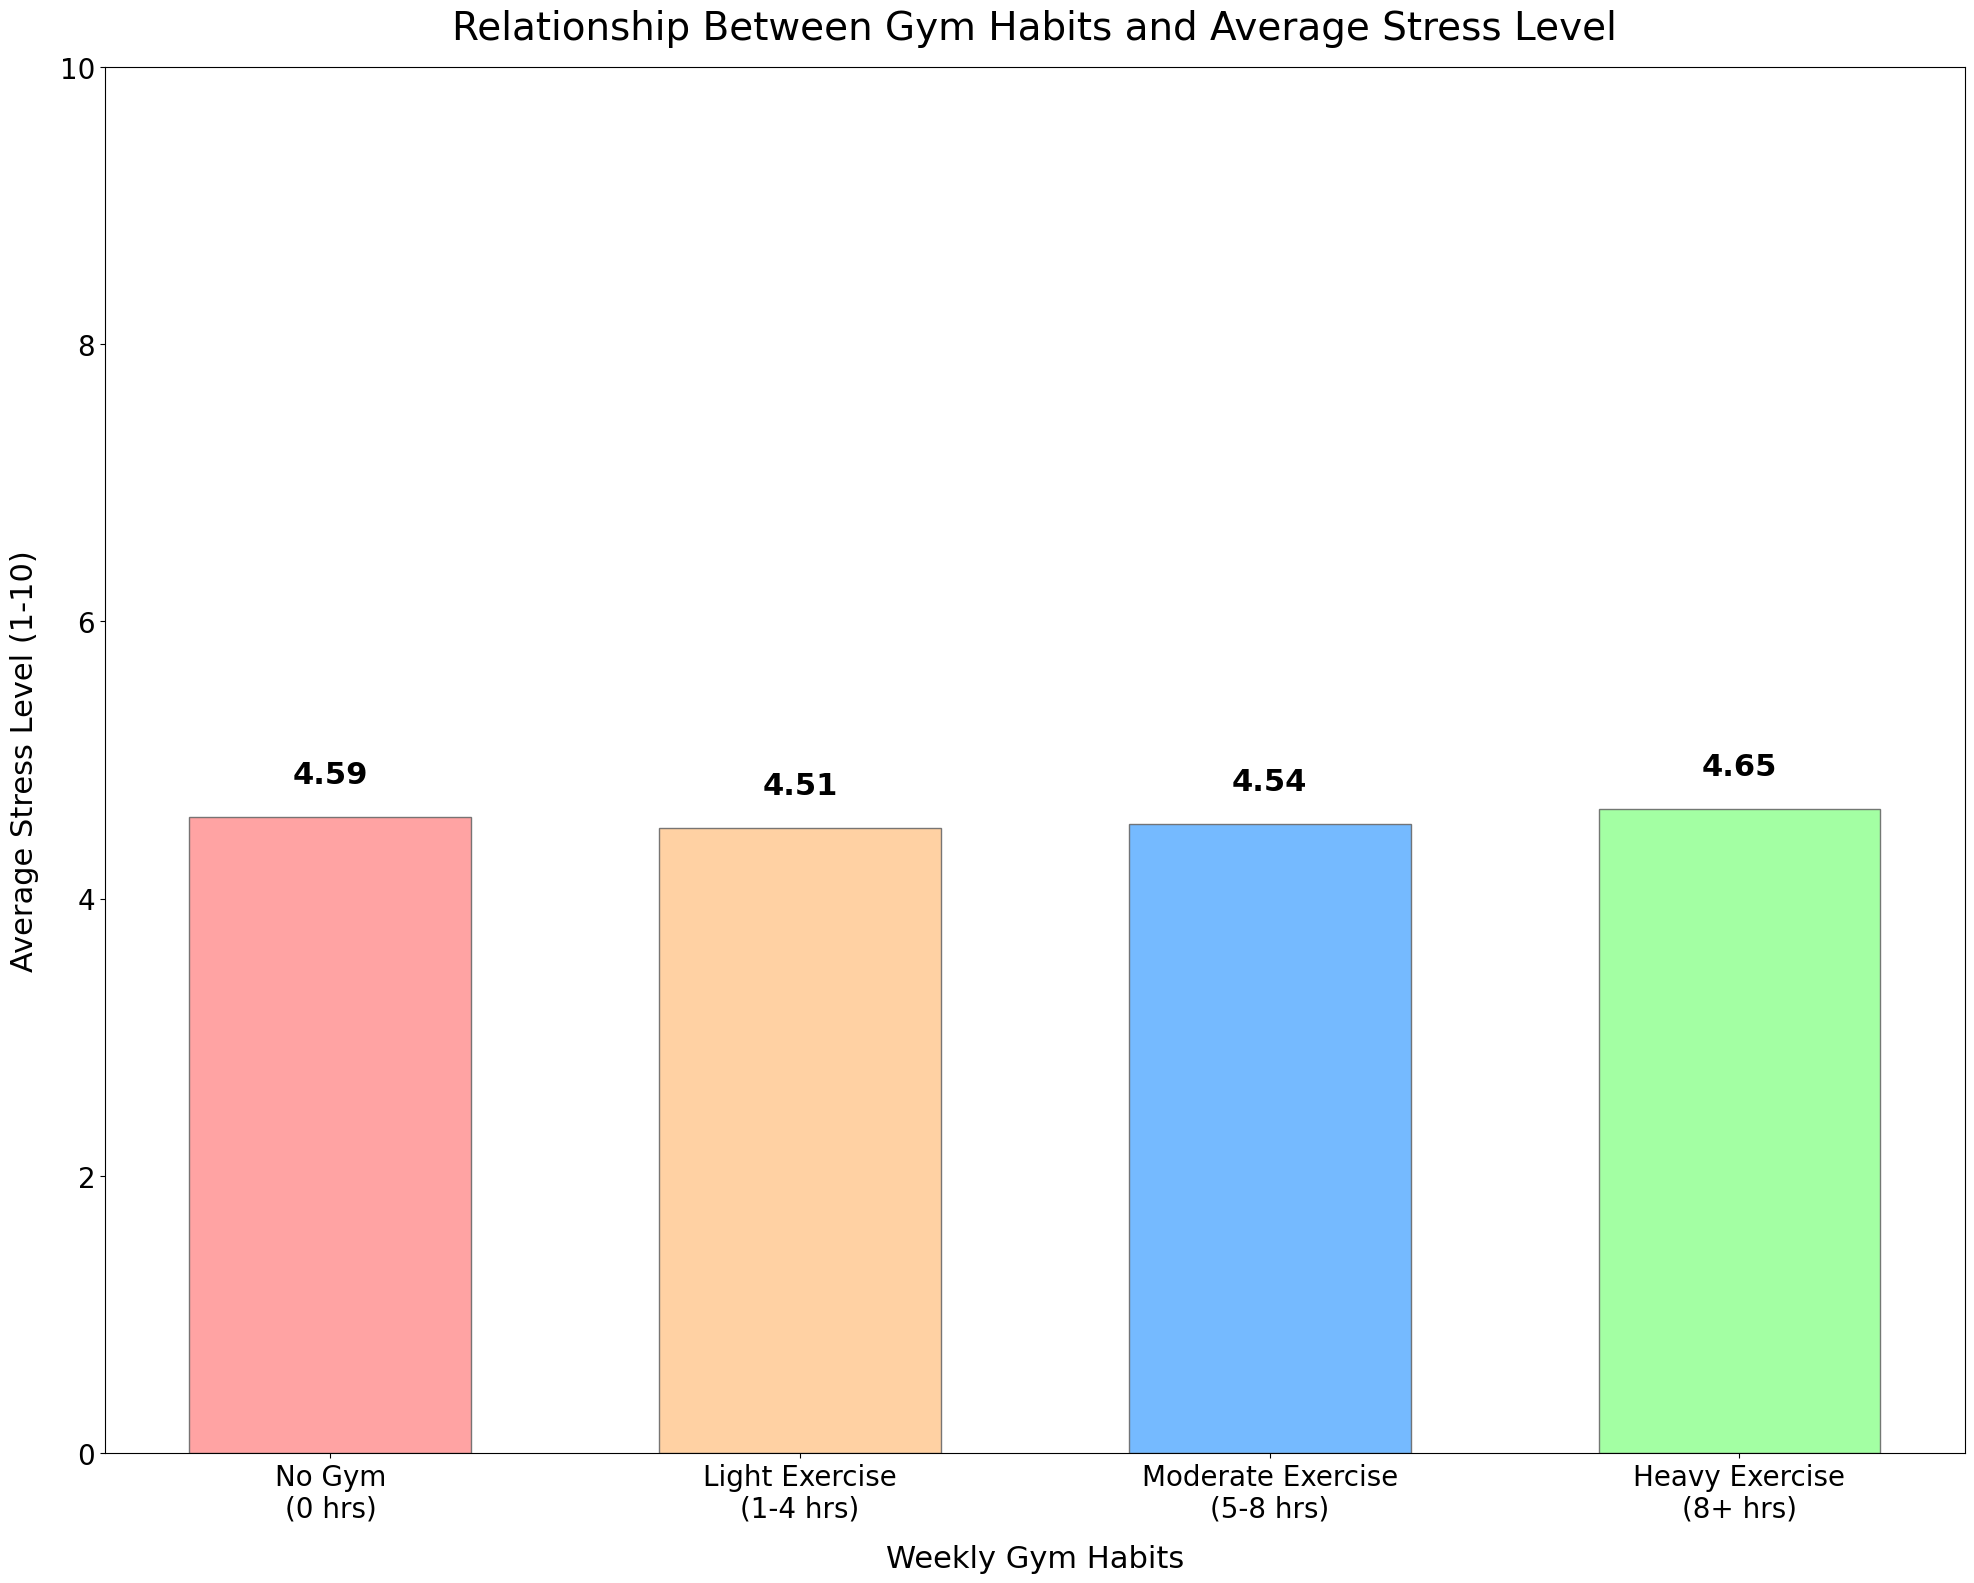

In [ ]:
# ---- Gym Habits and Stress Level Analysis ----
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(32, 24))
# 1. Categorize Gym Hours into 4 logical groups
def categorize_gym(hours):
    if hours == 0:
        return 'No Gym\n(0 hrs)'
    elif hours <= 4:
        return 'Light Exercise\n(1-4 hrs)'
    elif hours <= 8:
        return 'Moderate Exercise\n(5-8 hrs)'
    else:
        return 'Heavy Exercise\n(8+ hrs)'

# Apply the function to create a new column
df['Gym_Category'] = df['Gym_Hours_per_Week'].apply(categorize_gym)

# 2. Calculate average stress level for each category
# Define the logical order for the x-axis
category_order = ['No Gym\n(0 hrs)', 'Light Exercise\n(1-4 hrs)', 'Moderate Exercise\n(5-8 hrs)', 'Heavy Exercise\n(8+ hrs)']
avg_stress = df.groupby('Gym_Category')['Stress_Level_1_to_10'].mean().reindex(category_order)

# 3. Bar Chart
# Using different colors to distinguish categories
colors = ['#ff9999', '#ffcc99', '#66b3ff', '#99ff99']
bars = plt.bar(avg_stress.index, avg_stress.values, color=colors, edgecolor='dimgray', alpha=0.9, width=0.6)

# 4. Add data labels on top of each bar for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2,
             f'{yval:.2f}', ha='center', va='bottom', fontsize=32, fontweight='bold', color='black')

# 5. Titles and labels
plt.title('Relationship Between Gym Habits and Average Stress Level', fontsize=40, pad=20)
plt.xlabel('Weekly Gym Habits', fontsize=32, labelpad=15)
plt.ylabel('Average Stress Level (1-10)', fontsize=32, labelpad=15)

# 6. Axis tick parameters
plt.tick_params(axis='both', labelsize=32)

# 7. Set Y-axis limit to match the actual Stress Level scale (0 to 10)
plt.ylim(0, 10)
plt.show()